# Wyklad 5: GeoPandas — analiza danych przestrzennych poza QGIS
### Programowanie w GIS — Kurs dla studentow I stopnia

---

> **Kurs:** Programowanie w GIS (QGIS)  
> **Wyklad:** 5 z 7  
> **Tematy:** GeoDataFrame | Wczytywanie i zapis | CRS | Wizualizacja | Operacje przestrzenne | GeoPandas vs PyQGIS  
> **Wymagania wstepne:** Python, podstawy Pandas, Wyklad 3  

---

### Czym jest ten wyklad

Po trzech wykladach o PyQGIS robimy krok wstecz i patrzymy na dane przestrzenne
z innej perspektywy. **GeoPandas** pozwala analizowac dane wektorowe
calkowicie poza aplikacja QGIS — w Jupyterze, skryptach automatycznych,
pipeline'ach danych i srodowiskach serwerowych.

Ten notatnik dziala **bez QGIS** — uruchamiaj wszystkie komorki tutaj, w Jupyter.

---

### Instalacja

```bash
pip install geopandas matplotlib contextily mapclassify
```


## Spis tresci

1. [GeoPandas kontra PyQGIS — kiedy co uzyc](#s1)
2. [GeoDataFrame — struktura danych](#s2)
3. [Wczytywanie i zapis danych](#s3)
4. [Uklady wspolrzednych w GeoPandas](#s4)
5. [Filtrowanie i eksploracja atrybutow](#s5)
6. [Wizualizacja — od prostej mapy do choropletycznej](#s6)
7. [Operacje przestrzenne — overlay i spatial join](#s7)
8. [Dissolve — scalanie obiektow](#s8)
9. [Pomiary geometryczne](#s9)
10. [Podsumowanie i slownik pojec](#s10)


---
<a id='s1'></a>

## 1. GeoPandas kontra PyQGIS — kiedy co uzyc

Zanim zaczniemy, odpowiedzmy na pytanie ktore pojawi sie u kazdego studenta:
*po co uczyc sie GeoPandas skoro mamy PyQGIS?*

### 1.1 Fundamentalna roznica

| Cecha | PyQGIS | GeoPandas |
|---|---|---|
| Wymaga QGIS | Tak — dziala wewnatrz aplikacji | Nie — czysty Python |
| Interfejs | Obiektowy (warstwy, obiekty) | Tabelaryczny (DataFrame) |
| Srodowisko | Konsola QGIS, edytor skryptow | Jupyter, terminal, serwer |
| Wizualizacja | Obszar mapy QGIS | Matplotlib, wbudowana |
| Integracja z data science | Slaba | Doskonala (Pandas, NumPy, scikit-learn) |
| Dostep do Processing Toolbox | Tak | Nie |
| Edycja projektu QGIS | Tak | Nie |
| Automatyzacja na serwerze | Trudna | Naturalna |

### 1.2 Kiedy uzyc PyQGIS

- Pracujesz wewnatrz projektu QGIS i chcesz go modyfikowac.
- Potrzebujesz algorytmow Processing Toolbox.
- Tworzysz wtyczke z interfejsem graficznym.
- Chcesz automatyzowac operacje na otwartym projekcie.

### 1.3 Kiedy uzyc GeoPandas

- Piszesz skrypt ktory ma dzialac bez uruchamiania QGIS.
- Integrujesz dane przestrzenne z analiza danych (Pandas, Matplotlib, ML).
- Budujesz pipeline danych na serwerze lub w Jupyter.
- Chcesz szybko zbadac i zwizualizowac dane bez otwierania QGIS.
- Pracujesz w srodowisku gdzie QGIS nie jest dostepny.

### 1.4 Odpowiedz

Nie ma jednej lepszej opcji. Profesjonalny programista GIS
zna oba narzedzia i wybiera odpowiednie do zadania.
Czesto jedno uzupelnia drugie: GeoPandas do analizy i przygotowania danych,
PyQGIS do tworzenia projektów z dobrą wizualizacją kartograficzną.


---
<a id='s2'></a>

## 2. GeoDataFrame — struktura danych

### 2.1 Co to jest GeoDataFrame

`GeoDataFrame` to rozszerzenie `DataFrame` z biblioteki Pandas.
Dodaje do niego:

- kolumne `geometry` przechowujaca ksztalty obiektow (Shapely),
- metody przestrzenne: `.to_crs()`, `.buffer()`, `.sjoin()` i inne,
- atrybut `.crs` opisujacy uklad wspolrzednych.

Kazdy wiersz to jeden obiekt przestrzenny — odpowiednik `QgsFeature` z PyQGIS.

### 2.2 Analogia PyQGIS — GeoPandas

| PyQGIS | GeoPandas | Rola |
|---|---|---|
| `QgsVectorLayer` | `GeoDataFrame` | Warstwa wektorowa |
| `QgsFeature` | Wiersz GeoDataFrame | Pojedynczy obiekt |
| `QgsGeometry` | `shapely.geometry.*` | Ksztalt obiektu |
| `QgsFields` | Kolumny DataFrame | Schemat atrybutow |
| `layer.crs()` | `gdf.crs` | Uklad wspolrzednych |
| `layer.getFeatures()` | `gdf.iterrows()` / operacje wektorowe | Dostep do danych |

### 2.3 Podstawowa struktura

```
GeoDataFrame:
   name      pop_est  continent  geometry
0  Poland   37958138     Europe  MULTIPOLYGON(...)
1  Germany  83783942     Europe  MULTIPOLYGON(...)
2  France   67391582     Europe  MULTIPOLYGON(...)
   ...        ...          ...       ...

         ^atrybuty^              ^geometria^
```


In [1]:
# Instalacja (odkomentuj jesli potrzebne)
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install',
#     'geopandas', 'matplotlib', 'contextily', 'mapclassify', '-q'])

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'GeoPandas: {gpd.__version__}')
print(f'Pandas   : {pd.__version__}')

# Wczytaj wbudowany zbior danych
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

print(f'\nTyp obiektu  : {type(world)}')
print(f'Liczba wierszy: {len(world)}')
print(f'Kolumny      : {list(world.columns)}')
print(f'CRS          : {world.crs}')
print(f'Typ geometrii: {world.geom_type.unique()}')


GeoPandas: 1.0.1
Pandas   : 1.4.2



Typ obiektu  : <class 'geopandas.geodataframe.GeoDataFrame'>
Liczba wierszy: 177
Kolumny      : ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM

In [2]:
# Podglad danych — identycznie jak w Pandas
world.head(3)


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."


In [3]:
# Typy danych w kazdej kolumnie
print(world.dtypes)
print()

# Kolumna geometry ma specjalny typ
print(f'Typ kolumny geometry: {world.geometry.dtype}')
print(f'Przyklad geometrii  : {world.geometry[0].geom_type}')
print(f'WKT (fragment)      : {world.geometry[0].wkt[:60]}...')


featurecla      object
scalerank        int32
LABELRANK        int32
SOVEREIGNT      object
SOV_A3          object
                ...   
FCLASS_NL       object
FCLASS_SE       object
FCLASS_BD       object
FCLASS_UA       object
geometry      geometry
Length: 169, dtype: object

Typ kolumny geometry: geometry
Przyklad geometrii  : MultiPolygon
WKT (fragment)      : MULTIPOLYGON (((180 -16.067132663642447, 180 -16.55521656663...


---
<a id='s3'></a>

## 3. Wczytywanie i zapis danych

### 3.1 Wczytywanie — read_file()

`gpd.read_file()` czyta praktycznie kazdy format wektorowy:
Shapefile, GeoPackage, GeoJSON, KML, FlatGeobuf i wiele innych.
Pod spodem uzywa biblioteki Fiona (GDAL).

```python
# GeoPackage
gdf = gpd.read_file('dane.gpkg')

# Konkretna warstwa z GeoPackage
gdf = gpd.read_file('dane.gpkg', layer='granice_gmin')

# GeoJSON (rowniez z URL!)
gdf = gpd.read_file('https://.../.../data.geojson')

# Shapefile
gdf = gpd.read_file('warstwa.shp')

# Tylko fragmenta danych — przyspiesza wczytywanie
gdf = gpd.read_file('dane.gpkg', rows=slice(0, 100))
gdf = gpd.read_file('dane.gpkg', bbox=(14, 49, 24, 55))  # tylko obszar
```

### 3.2 Zapis — to_file()

```python
# GeoPackage (zalecany)
gdf.to_file('wynik.gpkg', driver='GPKG')

# GeoJSON
gdf.to_file('wynik.geojson', driver='GeoJSON')

# Shapefile
gdf.to_file('wynik.shp')  # domyslny driver

# Wiele warstw do jednego GeoPackage
gdf1.to_file('baza.gpkg', layer='panstwa', driver='GPKG')
gdf2.to_file('baza.gpkg', layer='stolice', driver='GPKG')
```

### 3.3 Tworzenie GeoDataFrame od podstaw

```python
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    {'nazwa': ['Wroclaw', 'Warszawa'],
     'pop':   [641000, 1794000]},
    geometry=[Point(17.038, 51.108), Point(21.012, 52.230)],
    crs='EPSG:4326'
)
```


In [4]:
import geopandas as gpd
from shapely.geometry import Point
import tempfile, os

# Wczytaj wbudowany zbior
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
cities = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places.zip")

print(f'Panstwa: {len(world)} obiektow')
print(f'Miasta : {len(cities)} obiektow')
print(f'Miasta — kolumny: {list(cities.columns)}')
print()
cities.head(5)


Panstwa: 177 obiektow
Miasta : 243 obiektow
Miasta — kolumny: ['SCALERANK', 'NATSCALE', 'LABELRANK', 'FEATURECLA', 'NAME', 'NAMEPAR', 'NAMEALT', 'NAMEASCII', 'ADM0CAP', 'CAPIN', 'WORLDCITY', 'MEGACITY', 'SOV0NAME', 'SOV_A3', 'ADM0NAME', 'ADM0_A3', 'ADM1NAME', 'ISO_A2', 'NOTE', 'LATITUDE', 'LONGITUDE', 'POP_MAX', 'POP_MIN', 'POP_OTHER', 'RANK_MAX', 'RANK_MIN', 'MEGANAME', 'LS_NAME', 'MAX_POP10', 'MAX_POP20', 'MAX_POP50', 'MAX_POP300', 'MAX_POP310', 'MAX_NATSCA', 'MIN_AREAKM', 'MAX_AREAKM', 'MIN_AREAMI', 'MAX_AREAMI', 'MIN_PERKM', 'MAX_PERKM', 'MIN_PERMI', 'MAX_PERMI', 'MIN_BBXMIN', 'MAX_BBXMIN', 'MIN_BBXMAX', 'MAX_BBXMAX', 'MIN_BBYMIN', 'MAX_BBYMIN', 'MIN_BBYMAX', 'MAX_BBYMAX', 'MEAN_BBXC', 'MEAN_BBYC', 'TIMEZONE', 'UN_FID', 'POP1950', 'POP1955', 'POP1960', 'POP1965', 'POP1970', 'POP1975', 'POP1980', 'POP1985', 'POP1990', 'POP1995', 'POP2000', 'POP2005', 'POP2010', 'POP2015', 'POP2020', 'POP2025', 'POP2050', 'MIN_ZOOM', 'WIKIDATAID', 'WOF_ID', 'CAPALT', 'NAME_EN', 'NAME_DE', 'NAME_ES', 

,SCALERANK,NATSCALE,LABELRANK,FEATURECLA,NAME,NAMEPAR,NAMEALT,NAMEASCII,ADM0CAP,CAPIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
0,8,10,3,Admin-0 capital,Vatican City,None,None,Vatican City,1,None,...,None,None,None,None,None,None,None,None,None,POINT (12.45339 41.90328)
1,7,20,0,Admin-0 capital,San Marino,None,None,San Marino,1,None,...,None,None,None,None,None,None,None,None,None,POINT (12.44177 43.9361)
2,7,20,0,Admin-0 capital,Vaduz,None,None,Vaduz,1,None,...,None,None,None,None,None,None,None,None,None,POINT (9.51667 47.13372)
3,6,30,8,Admin-0 capital alt,Lobamba,None,None,Lobamba,0,Legislative and,...,None,None,None,None,None,None,None,None,None,POINT (31.2 -26.46667)
4,6,30,8,Admin-0 capital,Luxembourg,None,None,Luxembourg,1,None,...,None,None,None,None,None,None,None,None,None,POINT (6.13 49.61166)


In [5]:
import geopandas as gpd
from shapely.geometry import Point
import tempfile, os

# Tworzenie GeoDataFrame od podstaw
dane = [
    ('Wroclaw',   17.038, 51.108,  641000),
    ('Warszawa',  21.012, 52.230, 1794000),
    ('Krakow',    19.945, 50.065,  779000),
    ('Gdansk',    18.646, 54.352,  470000),
    ('Poznan',    16.929, 52.407,  545000),
    ('Lodz',      19.455, 51.759,  672000),
]

gdf = gpd.GeoDataFrame(
    [{'miasto': n, 'lon': lo, 'lat': la, 'pop': p} for n, lo, la, p in dane],
    geometry=[Point(lo, la) for _, lo, la, _ in dane],
    crs='EPSG:4326'
)

print('Stworzona warstwa miast:')
print(gdf.to_string())
print(f'\nCRS: {gdf.crs}')

# Zapis do GeoJSON w katalogu tymczasowym
tmp = tempfile.mkdtemp()
sciezka = os.path.join(tmp, 'miasta_PL.geojson')
gdf.to_file(sciezka, driver='GeoJSON')
print(f'\nZapisano: {sciezka}')
print(f'Rozmiar : {os.path.getsize(sciezka):,} bajtow')

# Wczytaj ponownie i sprawdz
gdf2 = gpd.read_file(sciezka)
print(f'Wczytano: {len(gdf2)} obiektow, CRS: {gdf2.crs}')


Stworzona warstwa miast:
     miasto     lon     lat      pop               geometry
0   Wroclaw  17.038  51.108   641000  POINT (17.038 51.108)
1  Warszawa  21.012  52.230  1794000   POINT (21.012 52.23)
2    Krakow  19.945  50.065   779000  POINT (19.945 50.065)
3    Gdansk  18.646  54.352   470000  POINT (18.646 54.352)
4    Poznan  16.929  52.407   545000  POINT (16.929 52.407)
5      Lodz  19.455  51.759   672000  POINT (19.455 51.759)

CRS: EPSG:4326

Zapisano: C:\Users\kamil\AppData\Local\Temp\tmpoin6wnum\miasta_PL.geojson
Rozmiar : 1,199 bajtow
Wczytano: 6 obiektow, CRS: EPSG:4326


---
<a id='s4'></a>

## 4. Uklady wspolrzednych w GeoPandas

### 4.1 Sprawdzanie i ustawianie CRS

```python
# Sprawdz CRS
print(gdf.crs)          # pelny obiekt CRS
print(gdf.crs.to_epsg())  # kod EPSG jako liczba

# Ustaw CRS (gdy brakuje — NIE przelicza wspolrzednych)
gdf = gdf.set_crs('EPSG:4326')

# Reprojekcja (PRZELICZA wspolrzedne)
gdf_metr = gdf.to_crs('EPSG:2180')
```

### 4.2 set_crs vs to_crs — krytyczna roznica

| Metoda | Co robi | Kiedy uzywac |
|---|---|---|
| `.set_crs('EPSG:4326')` | Przypisuje CRS bez przeliczania | Gdy dane sa juz w tym ukladzie ale brak info o CRS |
| `.to_crs('EPSG:2180')` | Przelicza wspolrzedne do nowego ukladu | Gdy chcesz zmienic uklad |

> Uzywanie `set_crs` zamiast `to_crs` to jeden z najczestszych bledow.
> Jesli dane sa w EPSG:4326 i chcesz je miec w EPSG:2180,
> musisz uzyc `to_crs`, nie `set_crs`.

### 4.3 Reprojekcja calej warstwy

```python
# Reprojekcja z WGS84 do PL-1992
gdf_pl = gdf.to_crs('EPSG:2180')

# Sprawdz wspolrzedne po reprojekcji
print(gdf_pl.geometry[0].bounds)  # xmin, ymin, xmax, ymax w metrach
```


In [6]:
import geopandas as gpd
from shapely.geometry import Point

# Stworz prosty GeoDataFrame
gdf = gpd.GeoDataFrame(
    {'miasto': ['Wroclaw', 'Warszawa', 'Krakow']},
    geometry=[Point(17.038, 51.108), Point(21.012, 52.230), Point(19.945, 50.065)],
    crs='EPSG:4326'
)

print('Oryginal (EPSG:4326 — stopnie):')
for _, row in gdf.iterrows():
    print(f'  {row.miasto:<12} x={row.geometry.x:.4f}  y={row.geometry.y:.4f}')

# Reprojekcja do PL-1992
gdf_pl = gdf.to_crs('EPSG:2180')

print('\nPo to_crs(EPSG:2180) — metry:')
for _, row in gdf_pl.iterrows():
    print(f'  {row.miasto:<12} x={row.geometry.x:,.0f}  y={row.geometry.y:,.0f}')

# Reprojekcja do Web Mercator
gdf_wm = gdf.to_crs('EPSG:3857')

print('\nPo to_crs(EPSG:3857) — Web Mercator:')
for _, row in gdf_wm.iterrows():
    print(f'  {row.miasto:<12} x={row.geometry.x:,.0f}  y={row.geometry.y:,.0f}')


Oryginal (EPSG:4326 — stopnie):
  Wroclaw      x=17.0380  y=51.1080
  Warszawa     x=21.0120  y=52.2300
  Krakow       x=19.9450  y=50.0650

Po to_crs(EPSG:2180) — metry:
  Wroclaw      x=362,694  y=361,966
  Warszawa     x=637,368  y=486,790
  Krakow       x=567,613  y=244,621

Po to_crs(EPSG:3857) — Web Mercator:
  Wroclaw      x=1,896,661  y=6,640,420
  Warszawa     x=2,339,045  y=6,841,820
  Krakow       x=2,220,267  y=6,457,540


In [7]:
# Demonstracja bledu: set_crs zamiast to_crs
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    {'miasto': ['Wroclaw']},
    geometry=[Point(17.038, 51.108)],
    crs='EPSG:4326'
)

# DOBRZE: to_crs przelicza wspolrzedne
dobry = gdf.to_crs('EPSG:2180')
print(f'to_crs  : x={dobry.geometry[0].x:,.1f}  (metry — poprawne)')

# ZLE: set_crs tylko zmienia etykiete, nie przelicza
zly = gdf.set_crs('EPSG:2180', allow_override=True)
print(f'set_crs : x={zly.geometry[0].x:.4f}  (stopnie — BLEDNE!)')

print()
print('set_crs mowi: "te wspolrzedne sa w EPSG:2180"')
print('to_crs mowi : "przelicz wspolrzedne do EPSG:2180"')


to_crs  : x=362,694.0  (metry — poprawne)
set_crs : x=17.0380  (stopnie — BLEDNE!)

set_crs mowi: "te wspolrzedne sa w EPSG:2180"
to_crs mowi : "przelicz wspolrzedne do EPSG:2180"


---
<a id='s5'></a>

## 5. Filtrowanie i eksploracja atrybutow

GeoPandas dziedziczy wszystkie operacje Pandas.
Filtrowanie, grupowanie, sortowanie — wszystko dziala identycznie jak na DataFrame,
z tym ze wynik zachowuje informacje o geometrii i CRS.

### 5.1 Filtrowanie atrybutowe

```python
# Pojedynczy warunek
europa = world[world['continent'] == 'Europe']

# Wielokrotne warunki
duze_eu = world[
    (world['continent'] == 'Europe') &
    (world['pop_est'] > 10_000_000)
]

# Filtr przez isin()
wybrane = world[world['name'].isin(['Poland', 'Germany', 'France'])]
```

### 5.2 Operacje na kolumnach

```python
# Nowa kolumna
world['pop_mln'] = world['pop_est'] / 1_000_000

# Sortowanie
world.sort_values('pop_est', ascending=False).head(5)

# Grupowanie
world.groupby('continent')['pop_est'].sum()
```


In [8]:
import geopandas as gpd

world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# Filtrowanie — wynik to rowniez GeoDataFrame
europa = world[world['CONTINENT'] == 'Europe'].copy()
print(f'Kraje europejskie: {len(europa)}')
print(f'Typ wyniku: {type(europa)}')
print(f'CRS zachowane: {europa.crs}')


Kraje europejskie: 39
Typ wyniku: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS zachowane: EPSG:4326


In [9]:
import geopandas as gpd


# Statystyki per kontynent
statystyki = world.groupby('CONTINENT').agg(
    liczba_krajow=('NAME', 'count'),
    populacja_suma=('POP_EST', 'sum'),
    populacja_srednia=('POP_EST', 'mean'),
).round(0)

statystyki = statystyki.sort_values('populacja_suma', ascending=False)
print(statystyki.to_string())


                         liczba_krajow  populacja_suma  populacja_srednia
CONTINENT                                                                
Asia                                47    4.550277e+09         96814408.0
Africa                              51    1.306370e+09         25615102.0
Europe                              39    7.454125e+08         19113140.0
North America                       18    5.837560e+08         32430891.0
South America                       13    4.270667e+08         32851282.0
Oceania                              7    4.120487e+07          5886411.0
Antarctica                           1    4.490000e+03             4490.0
Seven seas (open ocean)              1    1.400000e+02              140.0


In [10]:
import geopandas as gpd

# Dodaj nowe kolumny obliczeniowe
world = world.copy()
world['pop_mln']    = (world['POP_EST'] / 1_000_000).round(2)
world['pkb_na_osobe'] = (world['GDP_MD'] * 1_000_000 / world['POP_EST']).round(0)

# TOP 10 wg PKB na osobe (min 1 mln mieszkancow)
top = (world[world['POP_EST'] > 1_000_000]
       .nlargest(10, 'pkb_na_osobe')
       [['NAME', 'CONTINENT', 'pop_mln', 'pkb_na_osobe']])

top.columns = ['Kraj', 'Kontynent', 'Pop (mln)', 'PKB/osoba (USD)']
print('TOP 10 wg PKB na osobe (kraje > 1 mln mieszkancow):')
print(top.to_string(index=False))


TOP 10 wg PKB na osobe (kraje > 1 mln mieszkancow):
         Kraj     Kontynent  Pop (mln)  PKB/osoba (USD)
  Timor-Leste          Asia       1.29           1560.0
      Estonia        Europe       1.33           1060.0
       Gambia        Africa       2.35            778.0
Guinea-Bissau        Africa       1.92            697.0
  Puerto Rico North America       3.19            598.0
     Botswana        Africa       2.30            504.0
     Slovakia        Europe       5.45            367.0
 Turkmenistan          Asia       5.94            354.0
       Kuwait          Asia       4.21            353.0
     Mongolia          Asia       3.23            345.0


---
<a id='s6'></a>

## 6. Wizualizacja — od prostej mapy do choropletycznej

### 6.1 Podstawowa mapa

```python
gdf.plot()  # najprostsza mozliwa mapa
```

### 6.2 Parametry plot()

| Parametr | Opis | Przyklad |
|---|---|---|
| `color` | Staly kolor wypelnienia | `'lightblue'` |
| `edgecolor` | Kolor krawedzi | `'grey'` |
| `linewidth` | Grubosc linii | `0.5` |
| `alpha` | Przezroczystosc (0-1) | `0.7` |
| `column` | Kolumna do choroplety | `'pop_est'` |
| `cmap` | Paleta kolorow | `'YlOrRd'` |
| `legend` | Wyswietl legende | `True` |
| `scheme` | Metoda klasyfikacji | `'quantiles'` |
| `figsize` | Rozmiar wykresu | `(15, 8)` |

### 6.3 Contextily — podklady mapowe

```python
import contextily as ctx

# Warstwa musi byc w EPSG:3857 (Web Mercator)
gdf_wm = gdf.to_crs('EPSG:3857')

ax = gdf_wm.plot(alpha=0.5, figsize=(12, 8))
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
```

### 6.4 Metody klasyfikacji (mapclassify)

| Schemat | Opis | Kiedy uzywac |
|---|---|---|
| `'quantiles'` | Rowna liczba obiektow w klasie | Rozkla znormalizowany |
| `'equal_interval'` | Rowne przedzialy wartosci | Rozkla jednostajny |
| `'natural_breaks'` | Przerwy w danych (Jenks) | Skupiska w danych |
| `'std_mean'` | Odchylenia od sredniej | Dane symetryczne |
| `'fisher_jenks'` | Wariant Jenks | Duze zbiory danych |


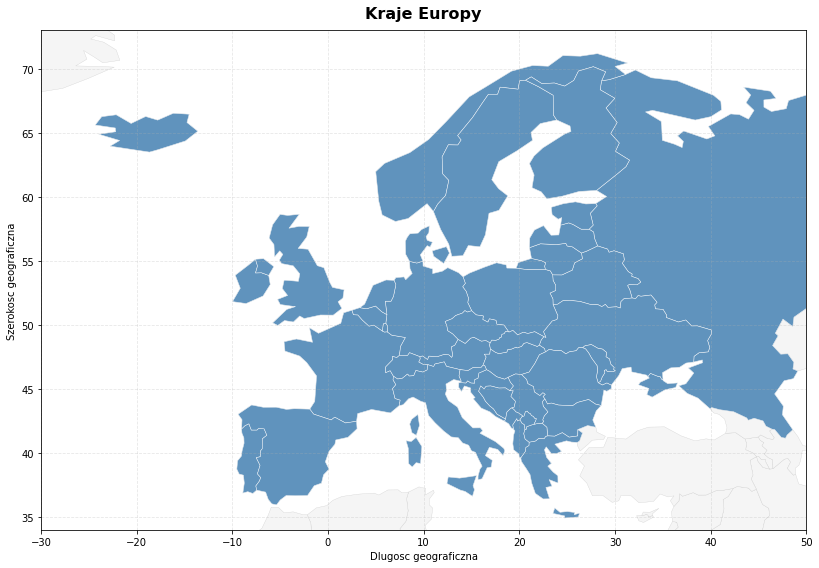

Panstwa europejskie na mapie: 39


In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
europa = world[world['CONTINENT'] == 'Europe'].copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Tlo — wszystkie panstwa
world.plot(ax=ax, color='#f5f5f5', edgecolor='#cccccc', linewidth=0.3)

# Europa — wyrozniamy kolor
europa.plot(ax=ax, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.85)

ax.set_title('Kraje Europy', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Dlugosc geograficzna')
ax.set_ylabel('Szerokosc geograficzna')
ax.set_xlim(-30, 50)
ax.set_ylim(34, 73)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print(f'Panstwa europejskie na mapie: {len(europa)}')


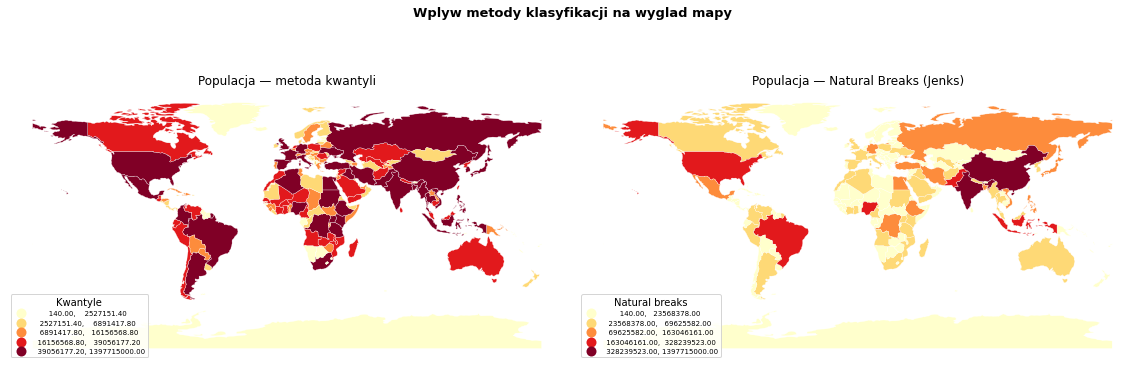

Te same dane, rozne metody — rozne mapy!


In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mapa 1: Choropleta populacji — kwantyle
world.plot(
    column='POP_EST',
    ax=axes[0],
    cmap='YlOrRd',
    scheme='quantiles',
    k=5,
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'loc': 'lower left', 'fontsize': 7, 'title': 'Kwantyle'}
)
axes[0].set_title('Populacja — metoda kwantyli', fontsize=12)
axes[0].axis('off')

# Mapa 2: Choropleta populacji — natural breaks
world.plot(
    column='POP_EST',
    ax=axes[1],
    cmap='YlOrRd',
    scheme='natural_breaks',
    k=5,
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'loc': 'lower left', 'fontsize': 7, 'title': 'Natural breaks'}
)
axes[1].set_title('Populacja — Natural Breaks (Jenks)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Wplyw metody klasyfikacji na wyglad mapy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Te same dane, rozne metody — rozne mapy!')


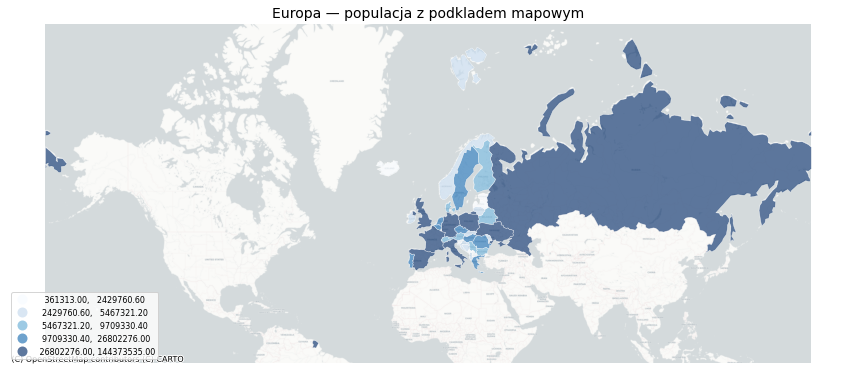

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

try:
    import contextily as ctx

    europa = world[world['CONTINENT'] == 'Europe'].copy()

    # Reprojekcja do EPSG:3857 — wymagane przez contextily
    europa_wm = europa.to_crs('EPSG:3857')

    fig, ax = plt.subplots(figsize=(12, 8))

    europa_wm.plot(
        ax=ax,
        column='POP_EST',
        cmap='Blues',
        alpha=0.65,
        edgecolor='white',
        linewidth=0.5,
        scheme='quantiles',
        legend=True,
        legend_kwds={'loc': 'lower left', 'fontsize': 8}
    )

    # Dodaj podklad mapowy OpenStreetMap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=4)

    ax.set_title('Europa — populacja z podkladem mapowym', fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

except ImportError:
    print('Zainstaluj contextily: pip install contextily')
    print('Pokazanie mapy bez podkladu:')

    europa = world[world['CONTINENT'] == 'Europe'].copy()
    fig, ax = plt.subplots(figsize=(10, 7))
    europa.plot(ax=ax, column='POP_EST', cmap='Blues', legend=True)
    ax.set_title('Europa — populacja (bez podkladu)')
    ax.axis('off')
    plt.show()


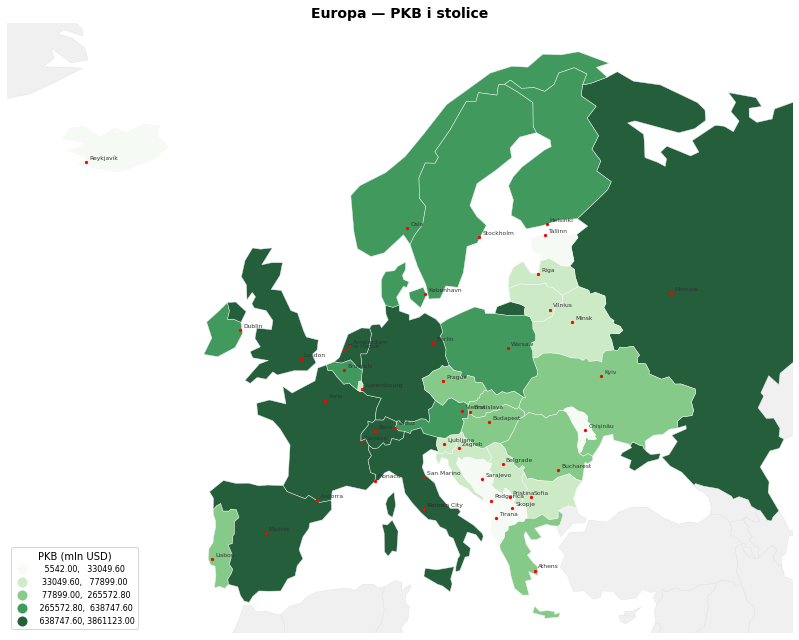

Stolice europejskie na mapie: 46


In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


europa = world[world['CONTINENT'] == 'Europe']
stolice_eu = cities[cities.geometry.within(
    europa.geometry.union_all()
)].copy()

fig, ax = plt.subplots(figsize=(13, 9))

# Warstwa 1: tlo swiata
world.plot(ax=ax, color='#f0f0f0', edgecolor='#dddddd', linewidth=0.3)

# Warstwa 2: Europa kolorow wg GDP
europa.plot(
    ax=ax, column='GDP_MD', cmap='Greens',
    edgecolor='white', linewidth=0.5, alpha=0.85,
    scheme='quantiles', legend=True,
    legend_kwds={'loc': 'lower left', 'fontsize': 8, 'title': 'PKB (mln USD)'}
)

# Warstwa 3: stolice
stolice_eu.plot(ax=ax, color='red', markersize=5, zorder=5)

# Etykiety miast
for _, row in stolice_eu.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3), textcoords='offset points',
        fontsize=6, color='#333333'
    )

ax.set_xlim(-30, 50)
ax.set_ylim(34, 73)
ax.set_title('Europa — PKB i stolice', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Stolice europejskie na mapie: {len(stolice_eu)}')


---
<a id='s7'></a>

## 7. Operacje przestrzenne — overlay i spatial join

### 7.1 Spatial Join — sjoin()

Spatial join laczy atrybuty dwoch warstw na podstawie relacji przestrzennej.
To odpowiednik SQL JOIN, ale warunkiem laczenia jest polozenie geograficzne.

```python
wynik = gpd.sjoin(
    lewa_gdf,          # lewa warstwa
    prawa_gdf,         # prawa warstwa
    how='left',        # typ join: 'left', 'right', 'inner'
    predicate='within' # relacja: 'within', 'intersects', 'contains'
)
```

Typy relacji w sjoin:

| predicate | Pytanie |
|---|---|
| `'within'` | Czy punkt lezy wewnatrz poligonu? |
| `'intersects'` | Czy geometrie maja wspolny obszar? |
| `'contains'` | Czy poligon zawiera punkt/geometrie? |

### 7.2 Overlay — naklada dane geometrycznie

```python
wynik = gpd.overlay(
    gdf1,
    gdf2,
    how='intersection'  # 'union', 'difference', 'symmetric_difference', 'identity'
)
```

Roznica overlay vs sjoin:

| | sjoin | overlay |
|---|---|---|
| Co robi | Laczy ATRYBUTY na podstawie relacji | Laczy GEOMETRIE i atrybuty |
| Wynik | Tabela atrybutow | Nowe geometrie (przeciecia) |
| Kiedy | Punkty w poligonach, kraje w kontynentach | Przeciecia stref, bufory vs obszary |


In [15]:
import geopandas as gpd


# Spatial join: przypisz kazdemu miestu kontynent i kraj
# predicate='within': miasto musi lezec wewnatrz panstwa
miasta_z_krajem = gpd.sjoin(
    cities,
    world[['NAME', 'CONTINENT', 'POP_EST', 'geometry']],
    how='left',
    predicate='within'
)

print(f'Miast przed sjoin : {len(cities)}')
print(f'Miast po sjoin    : {len(miasta_z_krajem)}')
print(f'Kolumny po sjoin  : {list(miasta_z_krajem.columns)}')
print()

# Statystyki: ile miast per kontynent
per_kontynent = (miasta_z_krajem
                 .groupby('CONTINENT')['NAME_left']
                 .count()
                 .sort_values(ascending=False)
                 .rename('liczba_miast'))

print('Liczba miast wg kontynentu:')
print(per_kontynent.to_string())


Miast przed sjoin : 243
Miast po sjoin    : 243
Kolumny po sjoin  : ['SCALERANK', 'NATSCALE', 'LABELRANK', 'FEATURECLA', 'NAME_left', 'NAMEPAR', 'NAMEALT', 'NAMEASCII', 'ADM0CAP', 'CAPIN', 'WORLDCITY', 'MEGACITY', 'SOV0NAME', 'SOV_A3', 'ADM0NAME', 'ADM0_A3', 'ADM1NAME', 'ISO_A2', 'NOTE', 'LATITUDE', 'LONGITUDE', 'POP_MAX', 'POP_MIN', 'POP_OTHER', 'RANK_MAX', 'RANK_MIN', 'MEGANAME', 'LS_NAME', 'MAX_POP10', 'MAX_POP20', 'MAX_POP50', 'MAX_POP300', 'MAX_POP310', 'MAX_NATSCA', 'MIN_AREAKM', 'MAX_AREAKM', 'MIN_AREAMI', 'MAX_AREAMI', 'MIN_PERKM', 'MAX_PERKM', 'MIN_PERMI', 'MAX_PERMI', 'MIN_BBXMIN', 'MAX_BBXMIN', 'MIN_BBXMAX', 'MAX_BBXMAX', 'MIN_BBYMIN', 'MAX_BBYMIN', 'MIN_BBYMAX', 'MAX_BBYMAX', 'MEAN_BBXC', 'MEAN_BBYC', 'TIMEZONE', 'UN_FID', 'POP1950', 'POP1955', 'POP1960', 'POP1965', 'POP1970', 'POP1975', 'POP1980', 'POP1985', 'POP1990', 'POP1995', 'POP2000', 'POP2005', 'POP2010', 'POP2015', 'POP2020', 'POP2025', 'POP2050', 'MIN_ZOOM', 'WIKIDATAID', 'WOF_ID', 'CAPALT', 'NAME_EN', 'NAME_DE', 

In [16]:
import geopandas as gpd


# Znajdz miasta ktore nie pasuja do zadnego panstwa
# (moga lezec na granicy lub brakuje im panstwa w danych)
miasta_z_krajem = gpd.sjoin(
    cities,
    world[['NAME', 'CONTINENT', 'geometry']],
    how='left', predicate='within'
)

bez_panstwa = miasta_z_krajem[miasta_z_krajem['NAME_right'].isna()]
print(f'Miasta bez przypisanego panstwa: {len(bez_panstwa)}')
if len(bez_panstwa) > 0:
    print(bez_panstwa[['NAME_left', 'geometry']].to_string())

# Dlaczego? Czesto granice 110m sa zbyt uproszczone
# i miasto wypada poza obrys kraju
print('\nPrzyczyna: uproszczenie geometrii 110m powoduje')
print('ze niektorych miast nie obejmuje obszar swojego panstwa.')


Miasta bez przypisanego panstwa: 30
          NAME_left                      geometry
5           Palikir     POINT (158.14997 6.91664)
6            Majuro          POINT (171.38 7.103)
7          Funafuti    POINT (179.21665 -8.51665)
8          Melekeok      POINT (134.62655 7.4874)
11           Tarawa     POINT (173.01757 1.33819)
12           Moroni    POINT (43.24024 -11.70416)
29           Roseau    POINT (-61.38701 15.30102)
30         Djibouti       POINT (43.148 11.59501)
35       Bridgetown      POINT (-59.61653 13.102)
38        Kingstown    POINT (-61.22024 13.15576)
39         Castries    POINT (-60.99288 14.00787)
40       Basseterre    POINT (-62.71701 17.30203)
41       Port Louis    POINT (57.49999 -20.16664)
42   Saint George's    POINT (-61.74164 12.05263)
43           Manama     POINT (50.58305 26.23614)
44     Saint John's    POINT (-61.85003 17.11804)
45       Montevideo   POINT (-56.18682 -34.90538)
53        Port Vila   POINT (168.31664 -17.73335)
64         Fre

Panstwa (lub ich czesci) w Europie Srodkowej: 19
           NAME           region
0        Russia  Europa Srodkowa
1        Sweden  Europa Srodkowa
2       Belarus  Europa Srodkowa
3       Ukraine  Europa Srodkowa
4        Poland  Europa Srodkowa
5       Austria  Europa Srodkowa
6       Hungary  Europa Srodkowa
7       Romania  Europa Srodkowa
8     Lithuania  Europa Srodkowa
9        Latvia  Europa Srodkowa
10      Germany  Europa Srodkowa
11      Croatia  Europa Srodkowa
12  Switzerland  Europa Srodkowa
13        Italy  Europa Srodkowa
14      Denmark  Europa Srodkowa
15     Slovenia  Europa Srodkowa
16     Slovakia  Europa Srodkowa
17      Czechia  Europa Srodkowa
18       Serbia  Europa Srodkowa


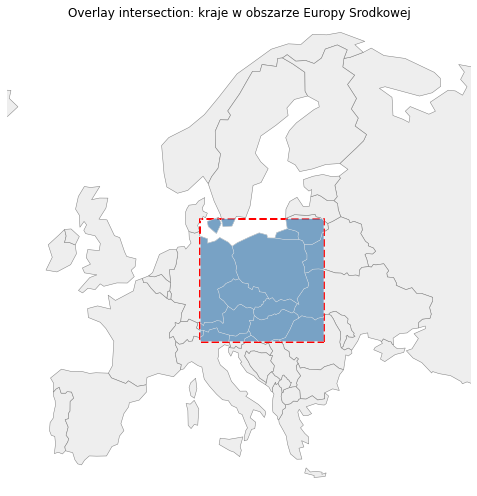

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box


europa = world[world['CONTINENT'] == 'Europe'].copy()

# Stworz prostokat reprezentujacy Europe Srodkowa
srodkowa = gpd.GeoDataFrame(
    {'region': ['Europa Srodkowa']},
    geometry=[box(10, 46, 26, 56)],
    crs='EPSG:4326'
)

# Overlay intersection: czesc Europy lezaca w prostokcie
wynik = gpd.overlay(europa, srodkowa, how='intersection')

print(f'Panstwa (lub ich czesci) w Europie Srodkowej: {len(wynik)}')
print(wynik[['NAME', 'region']].to_string())

# Wizualizacja
fig, ax = plt.subplots(figsize=(12, 7))
europa.plot(ax=ax, color='#eeeeee', edgecolor='grey', linewidth=0.5)
srodkowa.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')
wynik.plot(ax=ax, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.7)
ax.set_xlim(-15, 45)
ax.set_ylim(34, 72)
ax.set_title('Overlay intersection: kraje w obszarze Europy Srodkowej', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


---
<a id='s8'></a>

## 8. Dissolve — scalanie obiektow

### 8.1 Czym jest dissolve

`dissolve()` laczy geometrie obiektow nalezacych do tej samej grupy
i agreguje ich atrybuty. To odpowiednik SQL `GROUP BY` dla danych przestrzennych.

```python
# Scalenie panstw w kontynenty
kontynenty = world.dissolve(
    by='continent',           # pole grupowania
    aggfunc={
        'pop_est':    'sum',   # suma populacji
        'gdp_md_est': 'sum',   # suma PKB
        'name':       'count', # liczba krajow
    }
)
```

### 8.2 Typowe funkcje agregacji

| aggfunc | Opis |
|---|---|
| `'sum'` | Suma wartosci |
| `'mean'` | Srednia |
| `'count'` | Liczba obiektow |
| `'min'` / `'max'` | Minimum / maksimum |
| `'first'` / `'last'` | Pierwsza / ostatnia wartosc |


Przed dissolve: 177 panstw
Po dissolve   : 8 kontynentow

                              POP_EST  liczba_krajow
CONTINENT                                           
Asia                     4.550277e+09             47
Africa                   1.306370e+09             51
Europe                   7.454125e+08             39
North America            5.837560e+08             18
South America            4.270667e+08             13
Oceania                  4.120487e+07              7
Antarctica               4.490000e+03              1
Seven seas (open ocean)  1.400000e+02              1


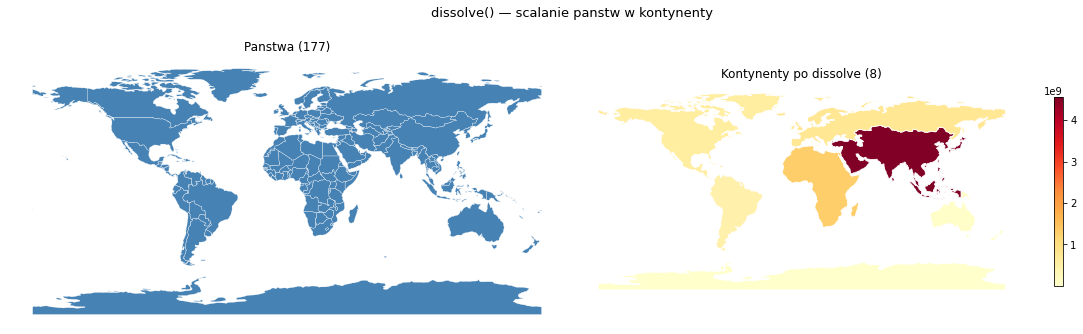

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt



# Dissolve: panstwa -> kontynenty
kontynenty = world.dissolve(
    by='CONTINENT',
    aggfunc={
        'POP_EST':    'sum',
        'GDP_MD': 'sum',
        'NAME':       'count',
    }
).rename(columns={'NAME': 'liczba_krajow'})

print(f'Przed dissolve: {len(world)} panstw')
print(f'Po dissolve   : {len(kontynenty)} kontynentow')
print()
print(kontynenty[['POP_EST', 'liczba_krajow']]
      .sort_values('POP_EST', ascending=False)
      .to_string())

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

world.plot(ax=axes[0], color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title(f'Panstwa ({len(world)})')
axes[0].axis('off')

kontynenty.plot(
    ax=axes[1], column='POP_EST',
    cmap='YlOrRd', edgecolor='white', linewidth=0.8,
    legend=True, legend_kwds={'shrink': 0.6}
)
axes[1].set_title(f'Kontynenty po dissolve ({len(kontynenty)})')
axes[1].axis('off')

plt.suptitle('dissolve() — scalanie panstw w kontynenty', fontsize=13)
plt.tight_layout()
plt.show()


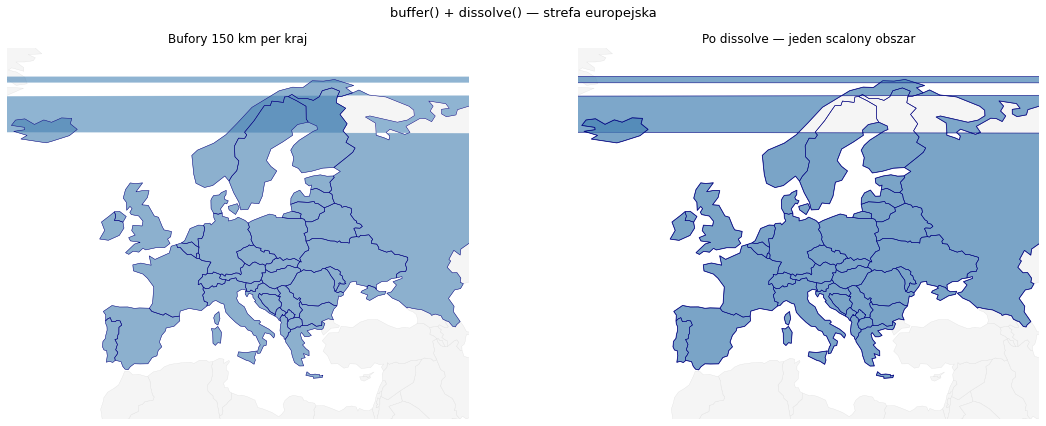

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
europa = world[world['CONTINENT'] == 'Europe'].copy()

# Reprodukcja do ETRS89-LAEA (metry, rowne pola)
europa_m = europa.to_crs('EPSG:3035')

# Bufor 150 km wokol kazdego kraju
europa_buf = europa_m.copy()
europa_buf['geometry'] = europa_m.geometry.buffer(1500)

# Dissolve — scal bufory w jeden obszar (bez grupowania)
obszar_europy = europa_buf.dissolve()

# Cofnij do WGS84
obszar_europy = obszar_europy.to_crs('EPSG:4326')
europa_buf_geo = europa_buf.to_crs('EPSG:4326')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

world.plot(ax=axes[0], color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)
europa_buf_geo.plot(ax=axes[0], color='steelblue', edgecolor='white',
                    linewidth=0.3, alpha=0.6)
europa.plot(ax=axes[0], color='none', edgecolor='navy', linewidth=0.5)
axes[0].set_xlim(-25, 50); axes[0].set_ylim(30, 75)
axes[0].set_title('Bufory 150 km per kraj')
axes[0].axis('off')

world.plot(ax=axes[1], color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)
obszar_europy.plot(ax=axes[1], color='steelblue', edgecolor='navy',
                   linewidth=0.8, alpha=0.7)
europa.plot(ax=axes[1], color='none', edgecolor='navy', linewidth=0.5)
axes[1].set_xlim(-25, 50); axes[1].set_ylim(30, 75)
axes[1].set_title('Po dissolve — jeden scalony obszar')
axes[1].axis('off')

plt.suptitle('buffer() + dissolve() — strefa europejska', fontsize=13)
plt.tight_layout()
plt.show()


---
<a id='s9'></a>

## 9. Pomiary geometryczne

### 9.1 Wbudowane wlasciwosci geometry

Operacje geometryczne w GeoPandas dzialaja na calej kolumnie naraz
(wektoryzacja przez NumPy), co jest znacznie szybsze niz petla w PyQGIS.

```python
# Pole powierzchni — w jednostkach CRS!
gdf['area'] = gdf.geometry.area

# Dlugosc
gdf['length'] = gdf.geometry.length

# Centroid
gdf['centroid'] = gdf.geometry.centroid

# Bounding box jako DataFrame
gdf['bounds'] = gdf.geometry.bounds  # xmin, ymin, xmax, ymax
```

### 9.2 Pomiary metryczne

Tak samo jak w PyQGIS — dla pomiarow fizycznych potrzebujemy ukladu metrycznego:

```python
# Reprojekcja do ETRS89-LAEA (rowne pola powierzchni dla Europy)
gdf_m = gdf.to_crs('EPSG:3035')

# Teraz area() zwraca m^2
gdf['area_km2'] = gdf_m.geometry.area / 1_000_000

# Dlugosc granic
gdf['dlugosc_granic_km'] = gdf_m.geometry.length / 1000
```


---
<a id='s10'></a>

## 10. Podsumowanie i slownik pojec

### 10.1 Co omowilismy na wykladzie 4

- porownanie GeoPandas i PyQGIS — rozne narzedzia do roznych zadan,
- `GeoDataFrame` — struktura danych, analogia do `QgsVectorLayer`,
- `read_file()` i `to_file()` — wczytywanie i zapis danych przestrzennych,
- `set_crs()` vs `to_crs()` — krytyczna roznica (przypisanie vs reprojekcja),
- filtrowanie i operacje na atrybutach — identycznie jak w Pandas,
- wizualizacja przez `plot()` — od prostej mapy do choropletycznej z mapclassify,
- podklady mapowe przez `contextily`,
- `sjoin()` — spatial join: laczenie atrybutow przez relacje przestrzenne,
- `overlay()` — operacje na geometriach: przeciecia, sumy, roznice,
- `dissolve()` — scalanie obiektow wg grupy z agregacja atrybutow,
- pomiary geometryczne — pole, dlugosc, centroid, wskaznik zwartosci.

### 10.2 Slownik najważniejszych metod i klas

| Pojecie | Definicja |
|---|---|
| **GeoDataFrame** | Rozszerzenie DataFrame z kolumna geometry i metodami przestrzennymi |
| **geometry** | Specjalna kolumna przechowujaca ksztalty obiektow (Shapely) |
| **read_file()** | Funkcja GeoPandas do wczytywania plikow wektorowych |
| **to_file()** | Metoda zapisu GeoDataFrame do pliku |
| **set_crs()** | Przypisuje CRS bez zmiany wspolrzednych |
| **to_crs()** | Reprojekcja — przelicza wspolrzedne do nowego CRS |
| **sjoin()** | Spatial join — laczenie atrybutow przez relacje przestrzenne |
| **overlay()** | Operacje geometryczne na dwoch warstwach |
| **dissolve()** | Scalanie obiektow wg grupy z agregacja atrybutow |
| **predicate** | Relacja przestrzenna uzywana w sjoin (within, intersects...) |
| **scheme** | Metoda klasyfikacji w mapach choropletycznych |
| **contextily** | Biblioteka do dodawania podkladow mapowych (OSM, CartoDB...) |
| **mapclassify** | Biblioteka metod klasyfikacji dla map choropletycznych |


## Literatura i zasoby

- GeoPandas dokumentacja: https://geopandas.org/en/stable/docs.html
- GeoPandas User Guide: https://geopandas.org/en/stable/docs/user_guide.html
- Contextily: https://contextily.readthedocs.io/
- Mapclassify: https://pysal.org/mapclassify/
- Geographic Data Science with Python (darmowy): https://geographicdata.science/book/

---
*Wyklad 5 — Programowanie w GIS (QGIS) — studia inżynierskie.*
